In [1]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [2]:
from diffusers import AmusedPipeline
pipe = AmusedPipeline.from_pretrained(
    "amused/amused-512",
    torch_dtype=torch.float16
).to("cuda")

# prompt = "surreal collage airport security checkpoint"
# image = pipe(prompt).images[0]
# image


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

vqvae/diffusion_pytorch_model.safetensor(…):   0%|          | 0.00/585M [00:00<?, ?B/s]

transformer/diffusion_pytorch_model.safe(…):   0%|          | 0.00/2.43G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
The AmusedPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


  0%|          | 0/12 [00:00<?, ?it/s]

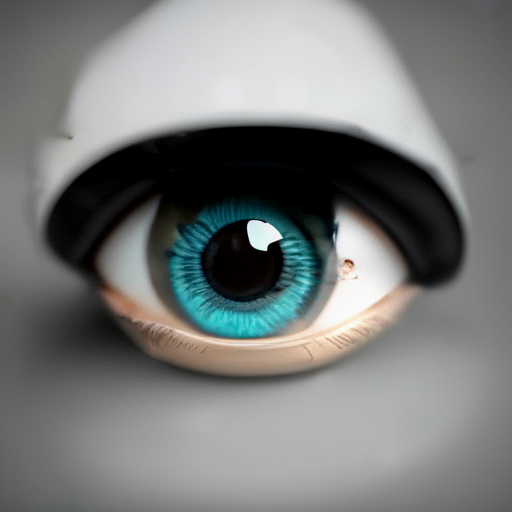

In [4]:
prompt = "eyes and security camera"
pipe(prompt).images[0]

In [5]:
import os, torch
from datetime import datetime
from PIL import Image

# -------------------------
# create unique output folder
# -------------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = f"A1_{timestamp}"
os.makedirs(out_dir, exist_ok=True)

prompts = [
"""Prompt 1/10: A man in the middle of a forest sitting on a couch and watching TV. The TV is not plugged into anything but is on and displaying a nature show. It has a soft glow. The man is only focused on the TV. There is moss starting to grow on the couch.""",

"""Prompt 2/10: A man in the middle of a forest sitting on a couch and watching TV. The TV is not plugged into anything but is on and displaying a nature show. It has a soft glow. The man is only focused on the TV. There is moss starting to grow on the couch. There are eyes watching the man in the background.""",

"""Prompt 3/10: A man in the middle of a forest sitting on a couch and watching TV. The TV is not plugged into anything but is on and displaying a nature show. It has a soft glow. The man is only focused on the TV. There is moss starting to grow on the couch. There are cords extending from the TV endlessly into the forest."""
]


for i, prompt in enumerate(prompts, start=1):
    base = f"A1_{i:02d}"

    # save prompt text
    with open(os.path.join(out_dir, f"{base}.txt"), "w", encoding="utf-8") as f:
        f.write(prompt)

    # generate image
    image = pipe(prompt).images[0]

    # save image
    image.save(
        os.path.join(out_dir, f"{base}.jpg"),
        quality=95
    )

print(f"✅ Done! Files saved in: {out_dir}")



NameError: name 'generator' is not defined